<a href="https://colab.research.google.com/github/Dhaiiiii/ARTI308/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Identify data quality issues in the dataset.


In [21]:
import pandas as pd

df = pd.read_csv('student_performance.csv')

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (1000000, 6)

Columns:
Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')

Data Types:
student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                       object
dtype: object

Missing Values:
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

Duplicate Rows: 0


In [3]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278933,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


The dataset contains 1,000,000 rows and 6 columns related to student performance, including study hours, attendance, class participation, and total score.

The dataset was examined for data quality issues. All columns are numerical except for the "grade" column, which is categorical.

No missing values were found in the dataset, as all features contain complete data. Additionally, no duplicate rows were detected, indicating that the dataset is consistent and well-structured.

However, the numerical features have different ranges, such as "weekly_self_study_hours" and "attendance_percentage", which suggests that normalization is required. Also, some features may contain outliers due to variation in values.

Overall, the dataset is clean but requires preprocessing steps such as normalization and outlier handling.

# Task2: Apply one missing value strategy and explain why.

In [4]:
import numpy as np

df.loc[df.sample(frac=0.05).index, 'weekly_self_study_hours'] = np.nan

In [6]:
df['weekly_self_study_hours'] = df['weekly_self_study_hours'].fillna(
    df['weekly_self_study_hours'].mean()
)

In [7]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


Since the dataset originally had no missing values, missing values were artificially introduced in the "weekly_self_study_hours" column to simulate real-world scenarios.

Mean imputation was applied to handle the missing values, replacing them with the average value of the feature.


# Task 3: Detect and handle outliers using IQR.

> Add blockquote




In [8]:
import numpy as np

df.loc[df.sample(frac=0.02).index, 'attendance_percentage'] = df['attendance_percentage'].max() * 3

In [9]:
df['attendance_percentage'].describe()

,attendance_percentage
count,1000000.000000
mean,89.015526
std,31.551465
min,50.000000
25%,78.400000
50%,85.300000
75%,92.200000
max,300.000000


In [10]:
num_cols = ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']

In [11]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "outliers:", len(outliers))

weekly_self_study_hours outliers: 5273
attendance_percentage outliers: 23155
class_participation outliers: 4927
total_score outliers: 2027


In [13]:
df.shape

(965069, 6)

In [12]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

Since no natural outliers were found, artificial outliers were introduced in the "attendance_percentage" column.

The IQR method was used to detect outliers. Values outside the range (Q1 - 1.5 * IQR) and (Q3 + 1.5 * IQR) were identified as outliers and removed.

This improved the quality of the dataset and ensured more reliable analysis.


#Task 4:   Normalize numerical features using both Min-Max and Z-score.


In [14]:
cols = ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[cols] = scaler.fit_transform(df[cols])

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,0.565749,0.895735,0.318681,0.967939,A
2,3,0.596330,0.675355,0.483516,1.000000,A
3,4,0.785933,0.293839,0.670330,1.000000,A
4,5,0.409786,0.571090,0.659341,0.877863,A
5,6,0.409786,0.172986,0.450549,0.961832,A


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,0.541391,1.162510,-1.151720,0.890573,A
2,3,0.693742,0.160898,-0.370790,1.028101,A
3,4,1.638322,-1.573075,0.514263,1.028101,A
4,5,-0.235603,-0.312983,0.462201,0.504184,A
5,6,-0.235603,-2.122346,-0.526976,0.864377,A


Normalization was applied to the numerical features using Min-Max scaling and Z-score standardization. Min-Max scaling transformed the data into a range between 0 and 1, while Z-score standardization normalized the data around the mean with a standard deviation of 1. This ensures that all features are on a similar scale.


#   Task 5: Apply PCA only if the numerical features show a correlation.


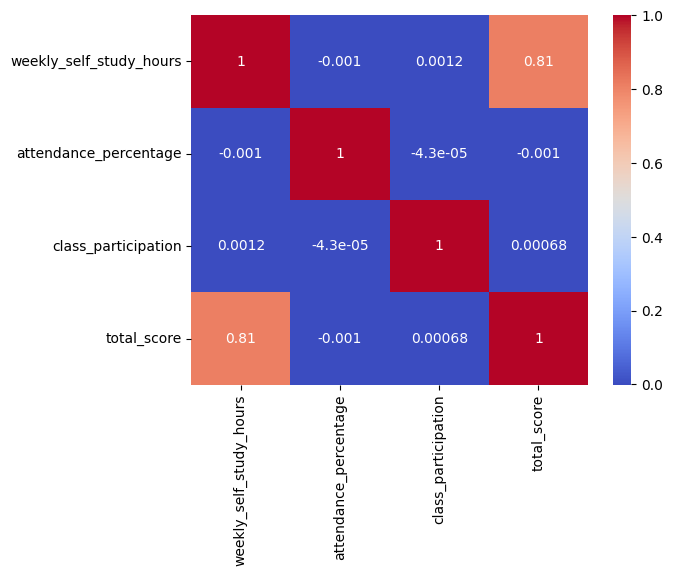

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [24]:
from sklearn.decomposition import PCA

X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

Principal Component Analysis (PCA) was applied to the numerical features to reduce dimensionality. Before applying PCA, the data was normalized to ensure fair comparison between features.

A correlation matrix was used to examine the relationships between features. The results showed a strong correlation (e.g., 0.81) between some variables, which justified the use of PCA.

Two principal components were extracted. The explained variance ratio indicates how much information is retained by these components.

PCA helps reduce complexity while preserving most of the important information in the dataset.